<a href="https://colab.research.google.com/github/Nikky316/MULTIPLE-LINEAR-REGRESSION-WORKFLOW/blob/main/multiple_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [32]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv")

df.head()

Saving c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv to c107fa55-45be-4f9c-8f61-088e88d1fb0c (3).csv


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [33]:
df_encoded = pd.get_dummies(df, columns=['TV', 'Influencer'], drop_first=True)


In [34]:
X = df_encoded.drop(columns=['Sales']).copy()

# FORCE CLEAN NUMERIC DATA
X = X.astype(float)

# REMOVE any NaN or infinite values (just in case)
X = X.replace([np.inf, -np.inf], np.nan).dropna()

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data

,Feature,VIF
0,Radio,6.695980
1,Social Media,5.344600
2,TV_Low,1.661129
3,TV_Medium,1.664554
4,Influencer_Mega,1.996014
5,Influencer_Micro,2.083851
6,Influencer_Nano,2.084801


In [36]:
X = df_encoded.drop(columns=['Sales']).astype(float)
y = df_encoded['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        15:58:22   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              217.4784      6.584  

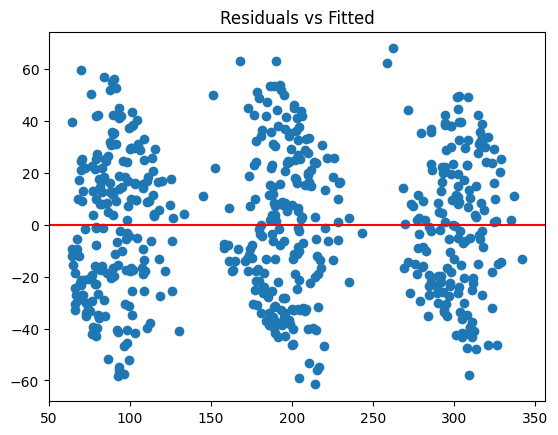

In [37]:
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.show()

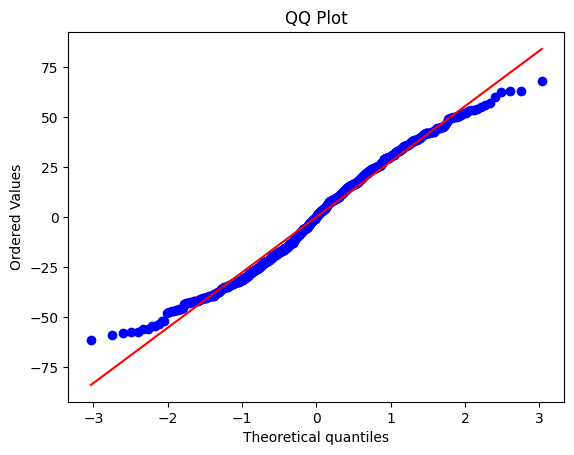

In [38]:
stats.probplot(model.resid, dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

## Regression Equation

Sales = 217.48
        + 2.97(Radio)
        - 0.14(Social Media)
        - 154.57(TV_Low)
        - 75.59(TV_Medium)
        + 2.49(Influencer_Mega)
        + 2.94(Influencer_Micro)
        + 0.80(Influencer_Nano)

## Model Interpretation

The Adjusted R-squared value (0.903) indicates that approximately 90.3% of the variation in Sales is explained by the model, showing a very strong fit.

Radio advertising has a positive and statistically significant effect on Sales (p < 0.05). This means that increasing Radio spend leads to higher Sales.

TV advertising is the strongest predictor:
- TV_Low and TV_Medium have large negative coefficients compared to the reference category (TV_High).
- This indicates that High TV advertising produces the highest Sales.

Social Media has a very small coefficient and is not statistically significant (p > 0.05), meaning it does not meaningfully impact Sales.

Influencer variables are also not statistically significant, indicating little measurable effect on Sales.

## Business Recommendation

Based on the regression analysis, marketing investments should prioritize TV and Radio advertising.

Radio shows a strong and statistically significant positive impact on Sales, making it a reliable channel for increasing revenue.

TV advertising, particularly at higher levels, contributes the most to Sales performance. Lower levels of TV advertising significantly reduce Sales outcomes.

Social Media and Influencer marketing do not show statistically significant effects, so increasing budget in these areas may not lead to improved results.

Therefore, companies should allocate a larger portion of their marketing budget to TV (at high levels) and Radio to maximize return on investment.

Variance Inflation Factor (VIF) was used to check for multicollinearity.

All variables have VIF values below the critical threshold (typically 5 or 10),
indicating that multicollinearity is not a major concern in the model.